In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF
from arch import arch_model
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


In [2]:
# Lista zmiennych ryzyka
tickers = {
    "USD_GBP": "GBPUSD=X",
    "USD_EUR": "EURUSD=X",
}

# Pobieranie danych od 2020 do końca 2024
raw_data = yf.download(list(tickers.values()), start="2020-01-01", end="2024-12-31", group_by='ticker')
adj_close = pd.DataFrame({name: raw_data[name]['Adj Close'] for name in tickers.values() if 'Adj Close' in raw_data[name]})
adj_close.columns = [k for k in tickers if tickers[k] in adj_close.columns]
adj_close = adj_close.dropna()
returns = adj_close.pct_change().dropna()

raw_data = yf.download(list(tickers.values()), start="2020-01-01", end="2024-12-31", group_by='ticker', auto_adjust=True)

# Zbieranie dostępnych serii danych
adj_close = pd.DataFrame()

for label, ticker in tickers.items():
    try:
        adj_close[label] = raw_data[ticker]['Close']
    except KeyError:
        print(f"Brak danych dla: {label} ({ticker})")

# Obliczanie dziennych zwrotów
returns = adj_close.pct_change().dropna()
log_returns = np.log(adj_close / adj_close.shift(1))
log_returns = log_returns.dropna()

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed


[*********************100%***********************]  2 of 2 completed


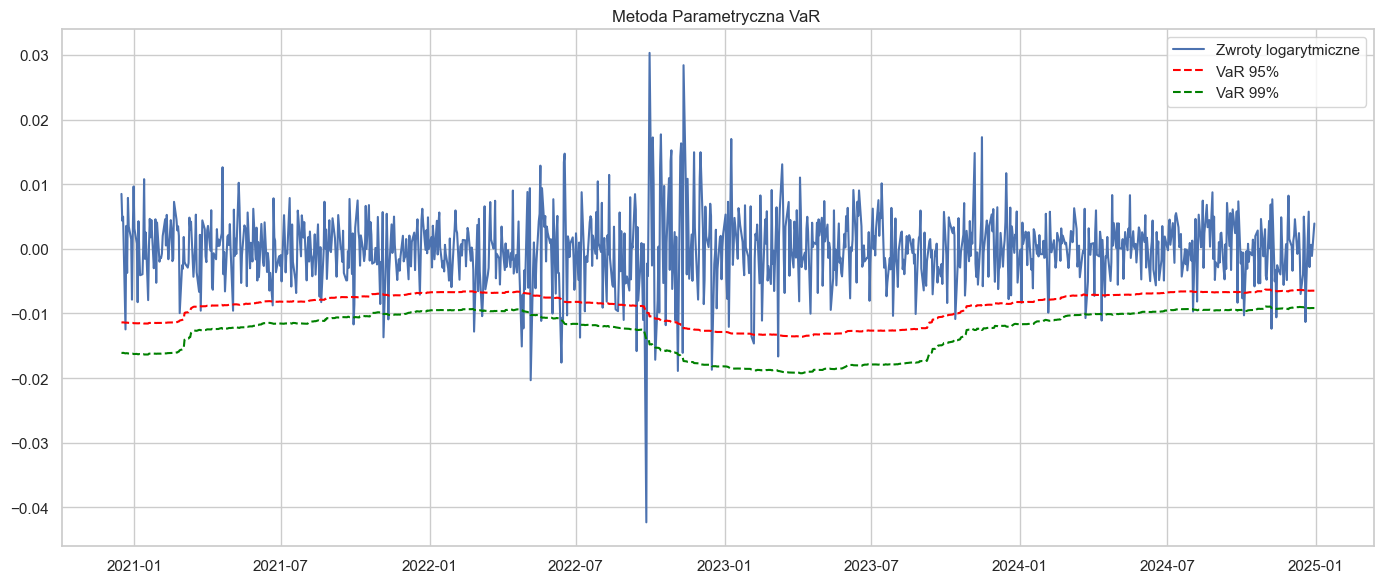

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parametry
period = 250
confidence_levels = [0.95, 0.99]

# Dane
tickers = {
    "USD_GBP": "GBPUSD=X",
    "USD_EUR": "EURUSD=X",
}

# Pobieranie danych
raw_data = yf.download(list(tickers.values()), start="2020-01-01", end="2024-12-31", group_by='ticker', auto_adjust=True)

# Zbieranie cen zamknięcia
adj_close = pd.DataFrame()
for label, ticker in tickers.items():
    try:
        adj_close[label] = raw_data[ticker]['Close']
    except KeyError:
        print(f"Brak danych dla: {label} ({ticker})")

# Logarytmiczne zwroty
log_returns = np.log(adj_close / adj_close.shift(1)).dropna()
returns = log_returns["USD_GBP"]  # wybierz jedną walutę

# Funkcja VaR
def parametric_var_series(returns, period=250, confidence_levels=[0.95, 0.99]):
    var_df = pd.DataFrame(index=returns.index)
    for conf in confidence_levels:
        alpha = 1 - conf
        z_score = norm.ppf(alpha)
        col_name = f"VaR_{int(conf*100)}"
        var_series = returns.rolling(window=period).std() * z_score
        var_df[col_name] = var_series
    return var_df.dropna()

# Oblicz VaR
var_df = parametric_var_series(returns, period=period, confidence_levels=confidence_levels)

# Dopasuj długości
aligned_returns = returns.loc[var_df.index]

# Wykres
plt.figure(figsize=(14, 6))
plt.plot(aligned_returns, label='Zwroty logarytmiczne')
plt.plot(var_df['VaR_95'], label='VaR 95%', color='red', linestyle='--')
plt.plot(var_df['VaR_99'], label='VaR 99%', color='green', linestyle='--')
plt.title('Metoda Parametryczna VaR ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Testowanie wsteczne ===

Poziom ufności 95.0%:
Liczba obserwacji: 1054
Oczekiwana liczba przekroczeń: 52.70
Rzeczywista liczba przekroczeń: 57
Wskaźnik przekroczeń: 5.41%

Poziom ufności 99.0%:
Liczba obserwacji: 1054
Oczekiwana liczba przekroczeń: 10.54
Rzeczywista liczba przekroczeń: 23
Wskaźnik przekroczeń: 2.18%

=== Test Kupca ===

Poziom ufności 95.0%:
Liczba obserwacji: 1054
Oczekiwana proporcja przekroczeń: 0.0500
Rzeczywista proporcja przekroczeń: 0.0541
Statystyka LR: 0.3602
P-value: 0.5484
Czy odrzucić H0 (na poziomie 5%): Nie

Poziom ufności 99.0%:
Liczba obserwacji: 1054
Oczekiwana proporcja przekroczeń: 0.0100
Rzeczywista proporcja przekroczeń: 0.0218
Statystyka LR: 11.1239
P-value: 0.0009
Czy odrzucić H0 (na poziomie 5%): Tak


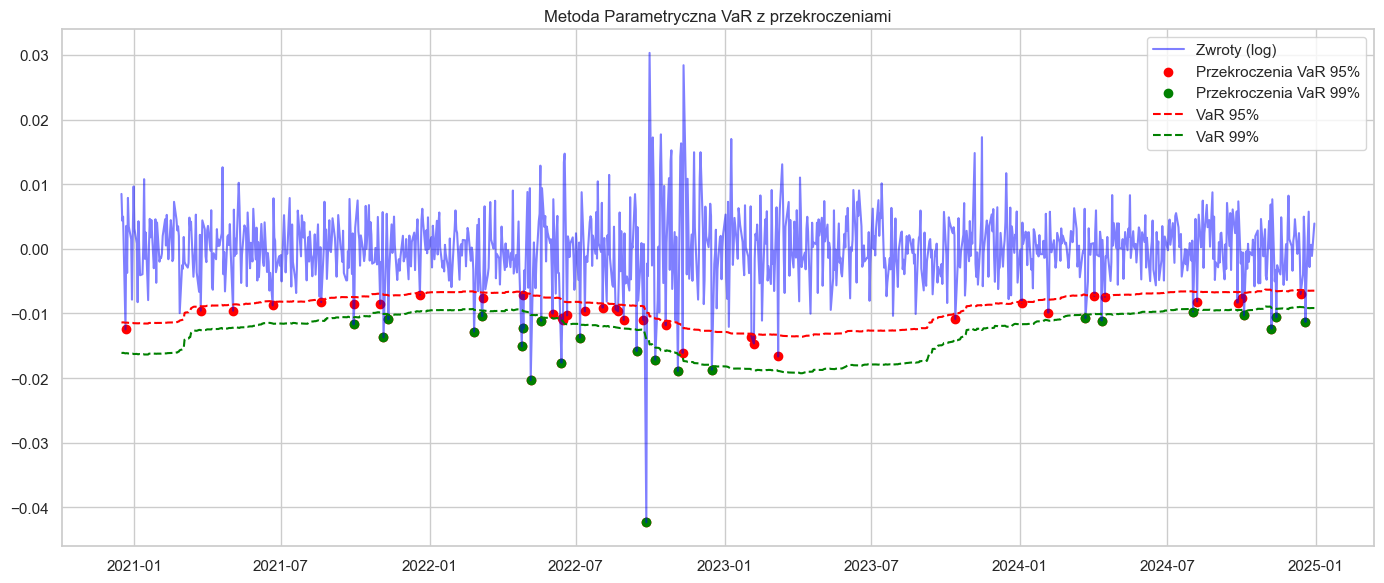

In [4]:
from scipy.stats import norm, binom
from scipy.stats import chi2

# Funkcja VaR
def parametric_var_series(returns, period=250, confidence_levels=[0.95, 0.99]):
    var_df = pd.DataFrame(index=returns.index)
    for conf in confidence_levels:
        alpha = 1 - conf
        z_score = norm.ppf(alpha)
        col_name = f"VaR_{int(conf*100)}"
        var_series = returns.rolling(window=period).std() * z_score
        var_df[col_name] = var_series
    return var_df.dropna()

var_df = parametric_var_series(returns, period=period, confidence_levels=confidence_levels)


## Testowanie wsteczne
def backtest_var(returns, var_series, confidence_level):
    exceedances = returns < var_series
    n_exceedances = exceedances.sum()
    n_obs = len(returns)
    expected_exceedances = (1 - confidence_level) * n_obs
    
    exceedance_rate = n_exceedances / n_obs
    
    return {
        'n_observations': n_obs,
        'n_exceedances': n_exceedances,
        'expected_exceedances': expected_exceedances,
        'exceedance_rate': exceedance_rate,
        'confidence_level': confidence_level
    }

## Test Kupca
def kupiec_test(returns, var_series, confidence_level):

    exceedances = returns < var_series
    n_exceedances = exceedances.sum()
    n_obs = len(returns)
    p = 1 - confidence_level  
    
    LR = -2 * (np.log(((1 - p)**(n_obs - n_exceedances) * p**n_exceedances)) - 
               np.log(((1 - n_exceedances/n_obs)**(n_obs - n_exceedances) * (n_exceedances/n_obs)**n_exceedances)))
    
    p_value = 1 - chi2.cdf(LR, df=1)
    
    return {
        'n_observations': n_obs,
        'n_exceedances': n_exceedances,
        'expected_proportion': p,
        'actual_proportion': n_exceedances/n_obs,
        'LR_statistic': LR,
        'p_value': p_value,
        'reject_null': p_value < 0.05  
    }


print("=== Testowanie wsteczne ===")
for conf in confidence_levels:
    var_col = f'VaR_{int(conf*100)}'
    backtest_results = backtest_var(aligned_returns, var_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {backtest_results['n_observations']}")
    print(f"Oczekiwana liczba przekroczeń: {backtest_results['expected_exceedances']:.2f}")
    print(f"Rzeczywista liczba przekroczeń: {backtest_results['n_exceedances']}")
    print(f"Wskaźnik przekroczeń: {backtest_results['exceedance_rate']*100:.2f}%")

print("\n=== Test Kupca ===")
for conf in confidence_levels:
    var_col = f'VaR_{int(conf*100)}'
    kupiec_results = kupiec_test(aligned_returns, var_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {kupiec_results['n_observations']}")
    print(f"Oczekiwana proporcja przekroczeń: {kupiec_results['expected_proportion']:.4f}")
    print(f"Rzeczywista proporcja przekroczeń: {kupiec_results['actual_proportion']:.4f}")
    print(f"Statystyka LR: {kupiec_results['LR_statistic']:.4f}")
    print(f"P-value: {kupiec_results['p_value']:.4f}")
    print(f"Czy odrzucić H0 (na poziomie 5%): {'Tak' if kupiec_results['reject_null'] else 'Nie'}")

plt.figure(figsize=(14, 6))
plt.plot(aligned_returns, label='Zwroty (log)', alpha=0.5, color='blue')

for conf in confidence_levels:
    var_col = f'VaR_{int(conf*100)}'
    exceedances = aligned_returns < var_df[var_col]
    plt.scatter(aligned_returns[exceedances].index, 
                aligned_returns[exceedances], 
                color='red' if conf == 0.95 else 'green',
                label=f'Przekroczenia VaR {int(conf*100)}%')

plt.plot(var_df['VaR_95'], label='VaR 95%', color='red', linestyle='--')
plt.plot(var_df['VaR_99'], label='VaR 99%', color='green', linestyle='--')
plt.title('Metoda Parametryczna VaR z przekroczeniami')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

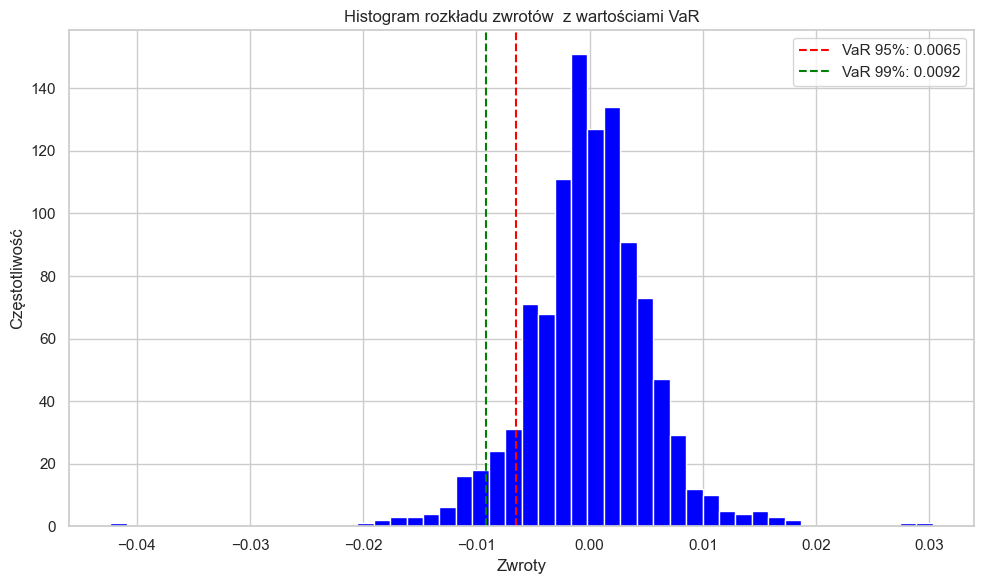

In [5]:
# Histogram z liniami VaR (bez procentów)
plt.figure(figsize=(10, 6))
plt.hist(aligned_returns, bins=50, color='blue')

for conf in confidence_levels:
    var_val = var_df[f"VaR_{int(conf*100)}"].iloc[-1]
    
    # Ustal kolor dla danego poziomu ufności
    color = 'green' if conf == 0.99 else 'red'
    
    plt.axvline(var_val, color=color, linestyle='--', label=f"VaR {int(conf*100)}%: {-var_val:.4f}")

plt.title("Histogram rozkładu zwrotów  z wartościami VaR")
plt.xlabel("Zwroty")
plt.ylabel("Częstotliwość")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


[*********************100%***********************]  2 of 2 completed


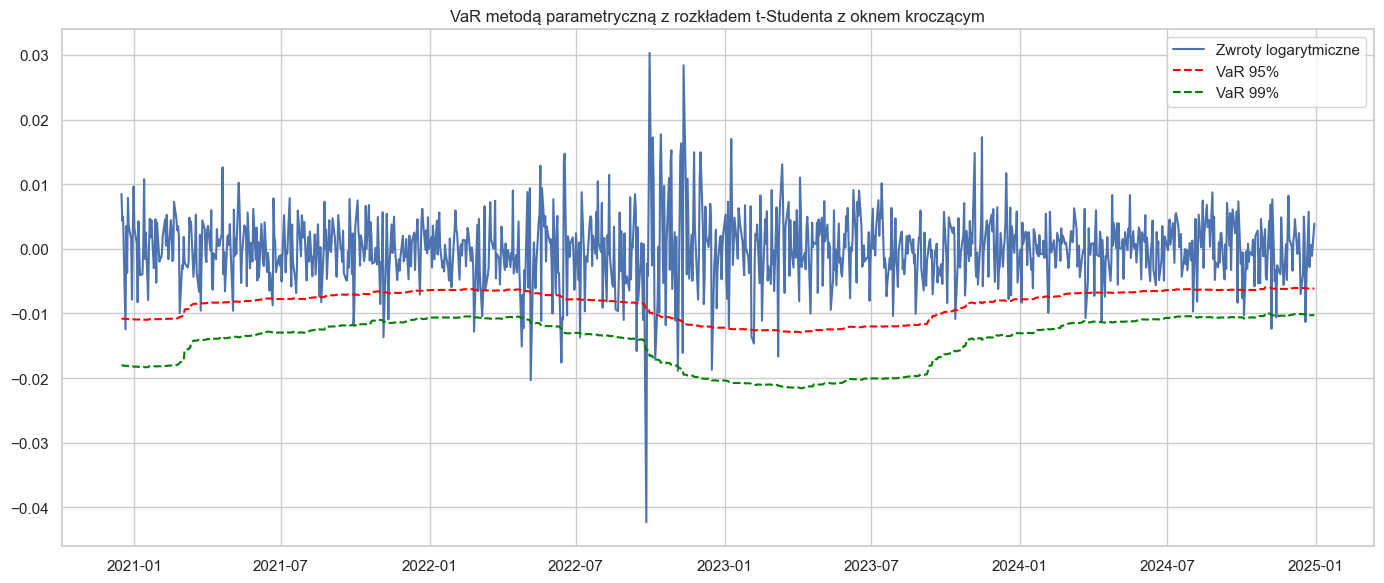

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Parametry
period = 250
confidence_levels = [0.95, 0.99]
df = 5  # stopnie swobody t-Studenta (możesz dopasować na podstawie danych)

# Dane
tickers = {
    "USD_GBP": "GBPUSD=X",
    "USD_EUR": "EURUSD=X",
}

# Pobieranie danych
raw_data = yf.download(list(tickers.values()), start="2020-01-01", end="2024-12-31", group_by='ticker', auto_adjust=True)

# Zbieranie cen zamknięcia
adj_close = pd.DataFrame()
for label, ticker in tickers.items():
    try:
        adj_close[label] = raw_data[ticker]['Close']
    except KeyError:
        print(f"Brak danych dla: {label} ({ticker})")

# Logarytmiczne zwroty
log_returns = np.log(adj_close / adj_close.shift(1)).dropna()
returns = log_returns["USD_GBP"]

# Funkcja VaR z rozkładem t-Studenta
def student_t_var_series(returns, period=250, confidence_levels=[0.95, 0.99], df=5):
    var_df = pd.DataFrame(index=returns.index)
    for conf in confidence_levels:
        alpha = 1 - conf
        t_score = t.ppf(alpha, df)
        col_name = f"VaR_{int(conf*100)}"
        
        # Skalowanie przez std * sqrt((df - 2)/df)
        rolling_std = returns.rolling(window=period).std()
        scale_factor = np.sqrt((df - 2) / df)
        var_series = rolling_std * t_score * scale_factor
        var_df[col_name] = var_series
    return var_df.dropna()

# Oblicz VaR
var_df = student_t_var_series(returns, period=period, confidence_levels=confidence_levels, df=df)

# Dopasuj długości
aligned_returns = returns.loc[var_df.index]

# Wykres
plt.figure(figsize=(14, 6))
plt.plot(aligned_returns, label='Zwroty logarytmiczne')
plt.plot(var_df['VaR_95'], label='VaR 95% ', color='red', linestyle='--')
plt.plot(var_df['VaR_99'], label='VaR 99% ', color='green', linestyle='--')
plt.title(f'VaR metodą parametryczną z rozkładem t-Studenta z oknem kroczącym')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Testowanie wsteczne ===

Poziom ufności 95.0%:
Liczba obserwacji: 1054
Oczekiwana liczba przekroczeń: 52.70
Rzeczywista liczba przekroczeń: 60
Wskaźnik przekroczeń: 5.69%

Poziom ufności 99.0%:
Liczba obserwacji: 1054
Oczekiwana liczba przekroczeń: 10.54
Rzeczywista liczba przekroczeń: 14
Wskaźnik przekroczeń: 1.33%

=== Test Kupca ===

Poziom ufności 95.0%:
Liczba obserwacji: 1054
Oczekiwana proporcja przekroczeń: 0.0500
Rzeczywista proporcja przekroczeń: 0.0569
Statystyka LR: 1.0208
P-value: 0.3123
Czy odrzucić H0 (na poziomie 5%): Nie

Poziom ufności 99.0%:
Liczba obserwacji: 1054
Oczekiwana proporcja przekroczeń: 0.0100
Rzeczywista proporcja przekroczeń: 0.0133
Statystyka LR: 1.0401
P-value: 0.3078
Czy odrzucić H0 (na poziomie 5%): Nie


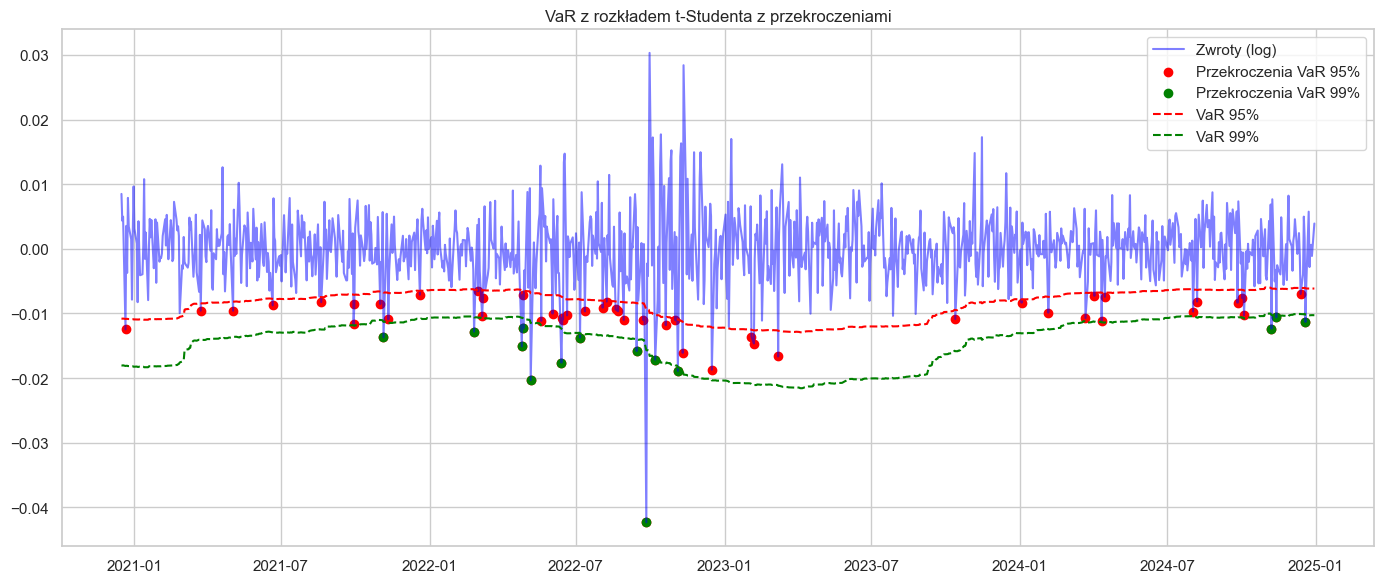

In [7]:
# Wyniki
print("=== Testowanie wsteczne ===")
for conf in confidence_levels:
    var_col = f'VaR_{int(conf*100)}'
    backtest_results = backtest_var(aligned_returns, var_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {backtest_results['n_observations']}")
    print(f"Oczekiwana liczba przekroczeń: {backtest_results['expected_exceedances']:.2f}")
    print(f"Rzeczywista liczba przekroczeń: {backtest_results['n_exceedances']}")
    print(f"Wskaźnik przekroczeń: {backtest_results['exceedance_rate']*100:.2f}%")

print("\n=== Test Kupca ===")
for conf in confidence_levels:
    var_col = f'VaR_{int(conf*100)}'
    kupiec_results = kupiec_test(aligned_returns, var_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {kupiec_results['n_observations']}")
    print(f"Oczekiwana proporcja przekroczeń: {kupiec_results['expected_proportion']:.4f}")
    print(f"Rzeczywista proporcja przekroczeń: {kupiec_results['actual_proportion']:.4f}")
    print(f"Statystyka LR: {kupiec_results['LR_statistic']:.4f}")
    print(f"P-value: {kupiec_results['p_value']:.4f}")
    print(f"Czy odrzucić H0 (na poziomie 5%): {'Tak' if kupiec_results['reject_null'] else 'Nie'}")

plt.figure(figsize=(14, 6))
plt.plot(aligned_returns, label='Zwroty (log)', alpha=0.5, color='blue')

for conf in confidence_levels:
    var_col = f'VaR_{int(conf*100)}'
    exceedances = aligned_returns < var_df[var_col]
    plt.scatter(aligned_returns[exceedances].index, 
                aligned_returns[exceedances], 
                color='red' if conf == 0.95 else 'green',
                label=f'Przekroczenia VaR {int(conf*100)}%')

plt.plot(var_df['VaR_95'], label='VaR 95%', color='red', linestyle='--')
plt.plot(var_df['VaR_99'], label='VaR 99%', color='green', linestyle='--')
plt.title('VaR z rozkładem t-Studenta z przekroczeniami')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

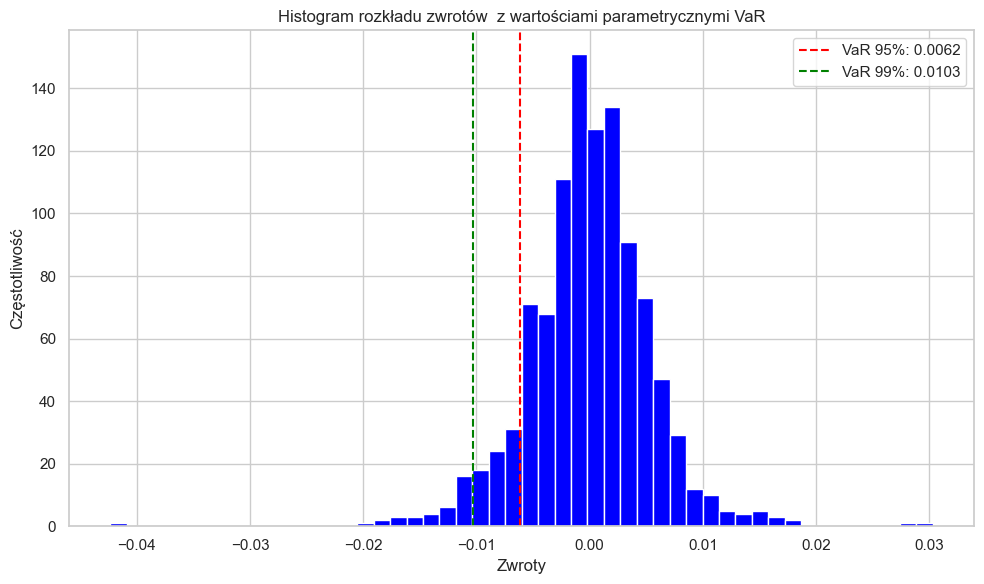

In [8]:
# Histogram z liniami VaR (bez procentów)
plt.figure(figsize=(10, 6))
plt.hist(aligned_returns, bins=50, color='blue')

for conf in confidence_levels:
    var_val = var_df[f"VaR_{int(conf*100)}"].iloc[-1]
    
    # Ustal kolor dla danego poziomu ufności
    color = 'green' if conf == 0.99 else 'red'
    
    plt.axvline(var_val, color=color, linestyle='--', label=f"VaR {int(conf*100)}%: {-var_val:.4f}")

plt.title("Histogram rozkładu zwrotów  z wartościami parametrycznymi VaR")
plt.xlabel("Zwroty")
plt.ylabel("Częstotliwość")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


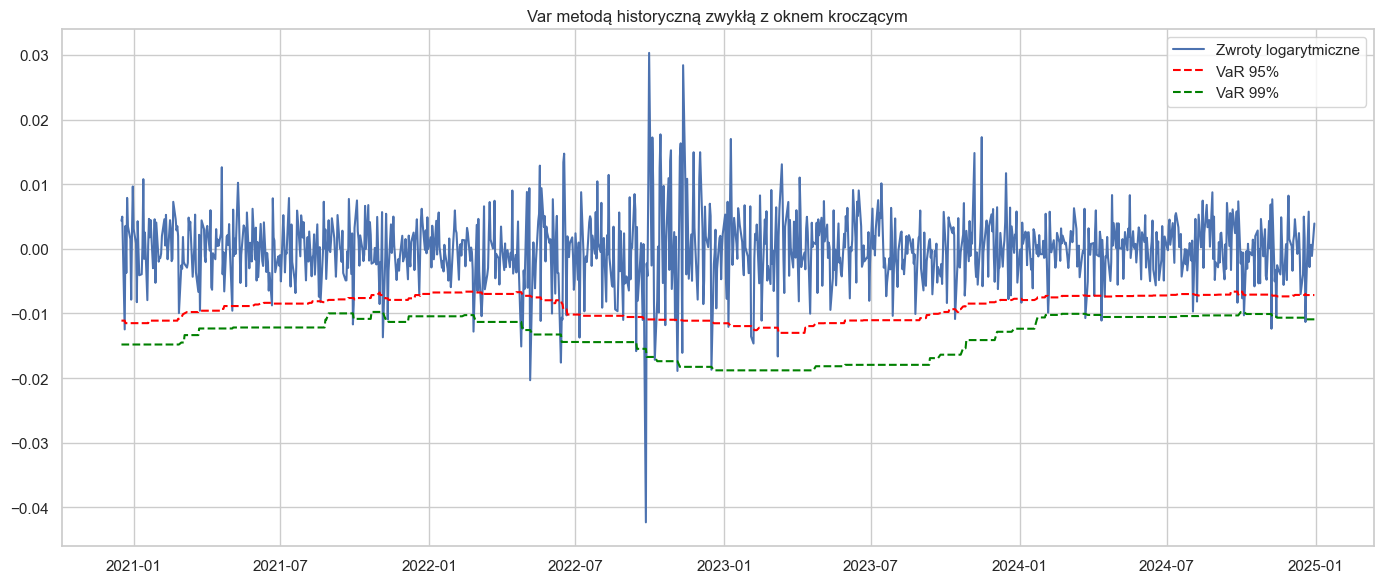

In [9]:
def historical_var_series(returns, period=250, confidence_levels=[0.95, 0.99]):
    """
    Oblicza historyczny VaR (rolling) dla zadanych poziomów ufności.

    Parametry:
        returns : pd.Series
            Seria zwrotów logarytmicznych lub procentowych.
        period : int
            Długość okna (rolling window).
        confidence_levels : list
            Lista poziomów ufności (np. [0.95, 0.99]).

    Zwraca:
        pd.DataFrame z kolumnami VaR dla każdego poziomu ufności.
    """
    var_df = pd.DataFrame(index=returns.index)

    for conf in confidence_levels:
        alpha = 1 - conf
        col_name = f"VaR_{int(conf*100)}"
        var_series = []

        for i in range(len(returns)):
            if i < period:
                var_series.append(np.nan)
            else:
                window_data = returns.iloc[i - period:i]
                var_val = np.percentile(window_data, alpha * 100)
                var_series.append(var_val)

        var_df[col_name] = var_series

    return var_df.dropna()
# Oblicz VaR
var_df = historical_var_series(returns, period=250, confidence_levels=[0.95, 0.99])

# Dopasuj długości
aligned_returns = returns.loc[var_df.index]

# Wykres
plt.figure(figsize=(14, 6))
plt.plot(aligned_returns, label='Zwroty logarytmiczne')
plt.plot(var_df['VaR_95'], label='VaR 95%', color='red', linestyle='--')
plt.plot(var_df['VaR_99'], label='VaR 99%', color='green', linestyle='--')
plt.title('Var metodą historyczną zwykłą z oknem kroczącym')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Testowanie wsteczne ===

Poziom ufności 95.0%:
Liczba obserwacji: 1053
Oczekiwana liczba przekroczeń: 52.65
Rzeczywista liczba przekroczeń: 52
Wskaźnik przekroczeń: 4.94%

Poziom ufności 99.0%:
Liczba obserwacji: 1053
Oczekiwana liczba przekroczeń: 10.53
Rzeczywista liczba przekroczeń: 19
Wskaźnik przekroczeń: 1.80%

=== Test Kupca ===

Poziom ufności 95.0%:
Liczba obserwacji: 1053
Oczekiwana proporcja przekroczeń: 0.0500
Rzeczywista proporcja przekroczeń: 0.0494
Statystyka LR: 0.0085
P-value: 0.9266
Czy odrzucić H0 (na poziomie 5%): Nie

Poziom ufności 99.0%:
Liczba obserwacji: 1053
Oczekiwana proporcja przekroczeń: 0.0100
Rzeczywista proporcja przekroczeń: 0.0180
Statystyka LR: 5.5570
P-value: 0.0184
Czy odrzucić H0 (na poziomie 5%): Tak


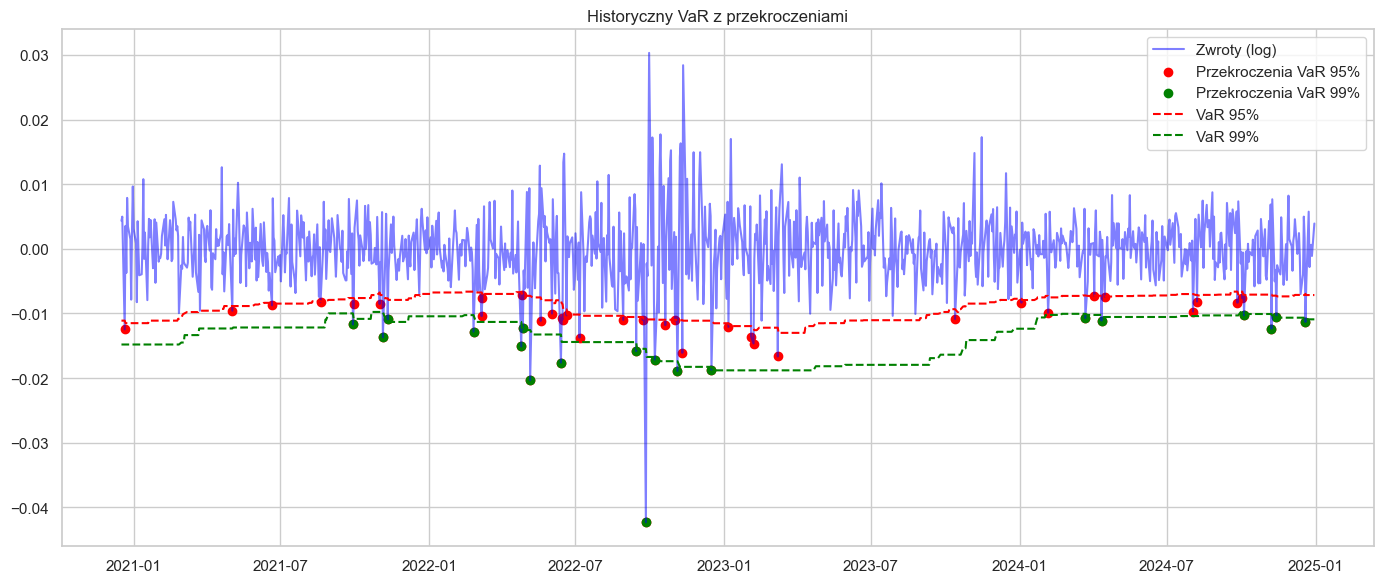

In [10]:
# Wyniki
print("=== Testowanie wsteczne ===")
for conf in [0.95, 0.99]:
    var_col = f'VaR_{int(conf*100)}'
    backtest_results = backtest_var(aligned_returns, var_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {backtest_results['n_observations']}")
    print(f"Oczekiwana liczba przekroczeń: {backtest_results['expected_exceedances']:.2f}")
    print(f"Rzeczywista liczba przekroczeń: {backtest_results['n_exceedances']}")
    print(f"Wskaźnik przekroczeń: {backtest_results['exceedance_rate']*100:.2f}%")

print("\n=== Test Kupca ===")
for conf in [0.95, 0.99]:
    var_col = f'VaR_{int(conf*100)}'
    kupiec_results = kupiec_test(aligned_returns, var_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {kupiec_results['n_observations']}")
    print(f"Oczekiwana proporcja przekroczeń: {kupiec_results['expected_proportion']:.4f}")
    print(f"Rzeczywista proporcja przekroczeń: {kupiec_results['actual_proportion']:.4f}")
    print(f"Statystyka LR: {kupiec_results['LR_statistic']:.4f}")
    print(f"P-value: {kupiec_results['p_value']:.4f}")
    print(f"Czy odrzucić H0 (na poziomie 5%): {'Tak' if kupiec_results['reject_null'] else 'Nie'}")

plt.figure(figsize=(14, 6))
plt.plot(aligned_returns, label='Zwroty (log)', alpha=0.5, color='blue')

for conf in [0.95, 0.99]:
    var_col = f'VaR_{int(conf*100)}'
    exceedances = aligned_returns < var_df[var_col]
    plt.scatter(aligned_returns[exceedances].index, 
                aligned_returns[exceedances], 
                color='red' if conf == 0.95 else 'green',
                label=f'Przekroczenia VaR {int(conf*100)}%')

plt.plot(var_df['VaR_95'], label='VaR 95%', color='red', linestyle='--')
plt.plot(var_df['VaR_99'], label='VaR 99%', color='green', linestyle='--')
plt.title('Historyczny VaR z przekroczeniami')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

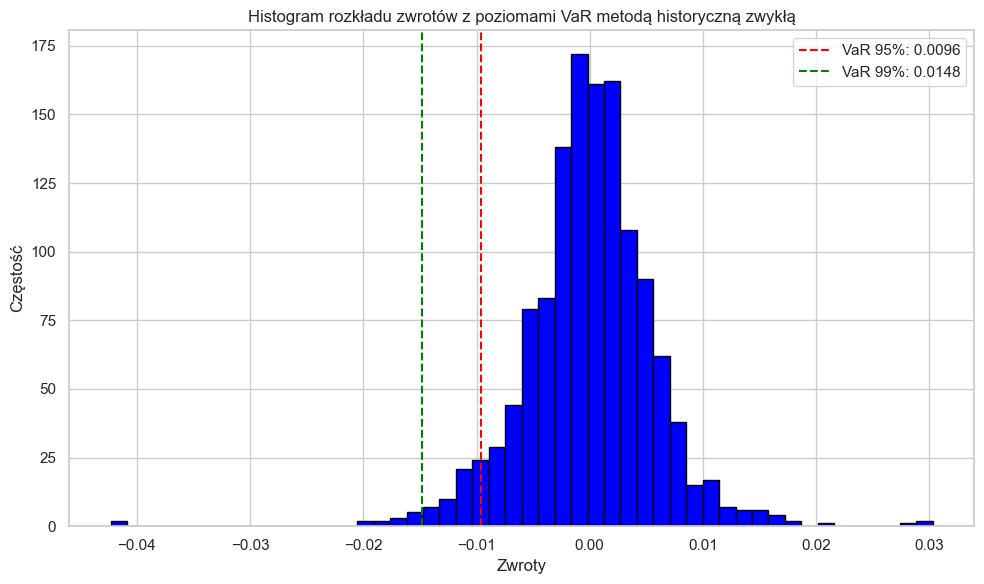

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, color='blue', edgecolor='black')

# Dodaj linie VaR
for conf in confidence_levels:
    var_value = np.percentile(returns, (1 - conf) * 100)
    color = 'green' if conf == 0.99 else 'red'
    plt.axvline(var_value, color=color, linestyle='--', label=f'VaR {int(conf*100)}%: {-var_value:.4f}')

plt.title("Histogram rozkładu zwrotów z poziomami VaR metodą historyczną zwykłą")
plt.xlabel("Zwroty")
plt.ylabel("Częstość")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


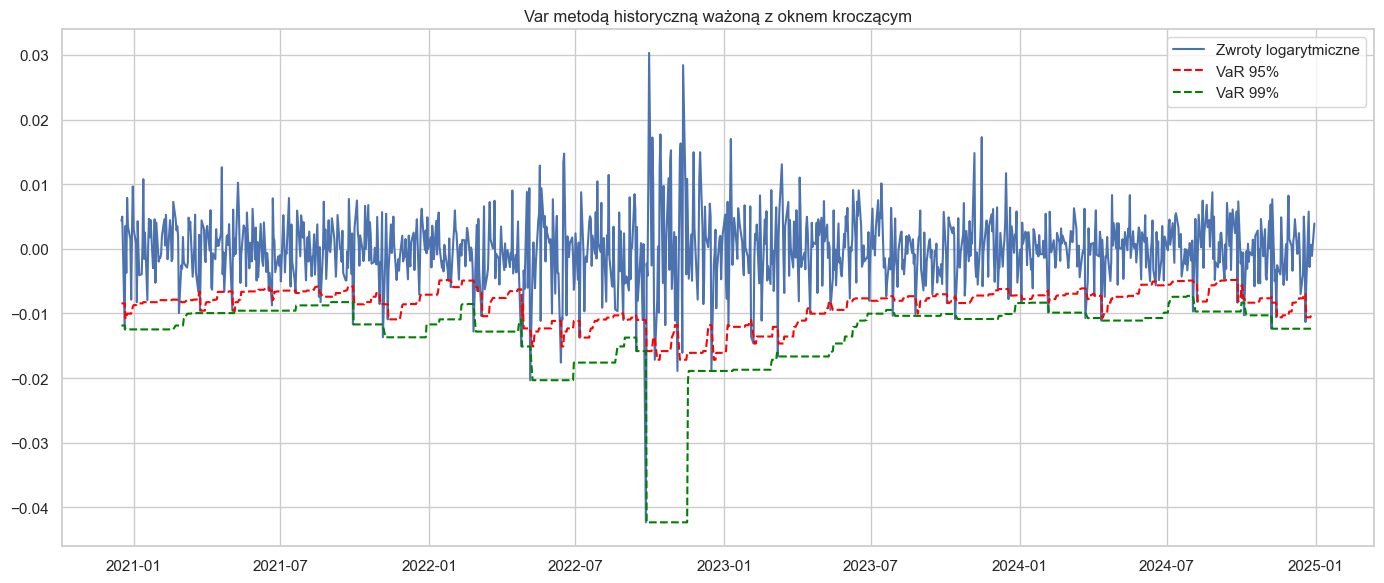

In [12]:
def weighted_historical_var_series(returns, period=250, confidence_levels=[0.95, 0.99], lam=0.97):
    """
    Oblicza Weighted Historical Simulation VaR (WHS-VaR) jako rolling window.
    
    Parametry:
        returns : pd.Series
            Seria zwrotów (logarytmicznych lub procentowych).
        period : int
            Długość rolling window.
        confidence_levels : list
            Lista poziomów ufności (np. [0.95, 0.99]).
        lam : float
            Parametr lambda ∈ (0, 1] - tempo spadku wag wykładniczych.

    Zwraca:
        pd.DataFrame z kolumnami VaR dla każdego poziomu ufności.
    """
    var_df = pd.DataFrame(index=returns.index)

    # Przygotuj wykładnicze wagi
    weights = np.array([lam**i for i in range(period)][::-1])  # w(t), w(t-1), ..., w(1)
    weights /= weights.sum()  # Normalizacja: sum(weights) = 1

    for conf in confidence_levels:
        var_series = []

        for i in range(len(returns)):
            if i < period:
                var_series.append(np.nan)
            else:
                window = returns.iloc[i - period:i].values
                sorted_idx = np.argsort(window)
                sorted_returns = window[sorted_idx]
                sorted_weights = weights[sorted_idx]
                cum_weights = np.cumsum(sorted_weights)

                # Szukamy pierwszego punktu, gdzie skumulowana waga przekracza poziom alfa
                alpha = 1 - conf
                idx = np.searchsorted(cum_weights, alpha)
                var_value = sorted_returns[idx]
                var_series.append(var_value)

        var_df[f"WHSVaR_{int(conf*100)}"] = var_series

    return var_df.dropna()
# Parametry
period = 250
confidence_levels = [0.95, 0.99]
lam = 0.97

# Oblicz WHS-VaR
whs_var_df = weighted_historical_var_series(returns, period=period, confidence_levels=confidence_levels, lam=lam)

# Dopasuj zwroty do długości WHS-VaR
aligned_returns = returns.loc[whs_var_df.index]

# Wykres
plt.figure(figsize=(14, 6))
plt.plot(aligned_returns, label='Zwroty logarytmiczne')
plt.plot(whs_var_df[f'WHSVaR_95'], label='VaR 95%', linestyle='--', color='red')
plt.plot(whs_var_df[f'WHSVaR_99'], label='VaR 99%', linestyle='--', color='green')
plt.title('Var metodą historyczną ważoną z oknem kroczącym')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



=== Testowanie wsteczne - Ważony Historyczny VaR ===

Poziom ufności 95.0%:
Liczba obserwacji: 1053
Oczekiwana liczba przekroczeń: 52.65
Rzeczywista liczba przekroczeń: 57
Wskaźnik przekroczeń: 5.41%

Poziom ufności 99.0%:
Liczba obserwacji: 1053
Oczekiwana liczba przekroczeń: 10.53
Rzeczywista liczba przekroczeń: 17
Wskaźnik przekroczeń: 1.61%

=== Test Kupca - Ważony Historyczny VaR ===

Poziom ufności 95.0%:
Liczba obserwacji: 1053
Oczekiwana proporcja przekroczeń: 0.0500
Rzeczywista proporcja przekroczeń: 0.0541
Statystyka LR: 0.3688
P-value: 0.5436
Czy odrzucić H0 (na poziomie 5%): Nie

Poziom ufności 99.0%:
Liczba obserwacji: 1053
Oczekiwana proporcja przekroczeń: 0.0100
Rzeczywista proporcja przekroczeń: 0.0161
Statystyka LR: 3.3857
P-value: 0.0658
Czy odrzucić H0 (na poziomie 5%): Nie


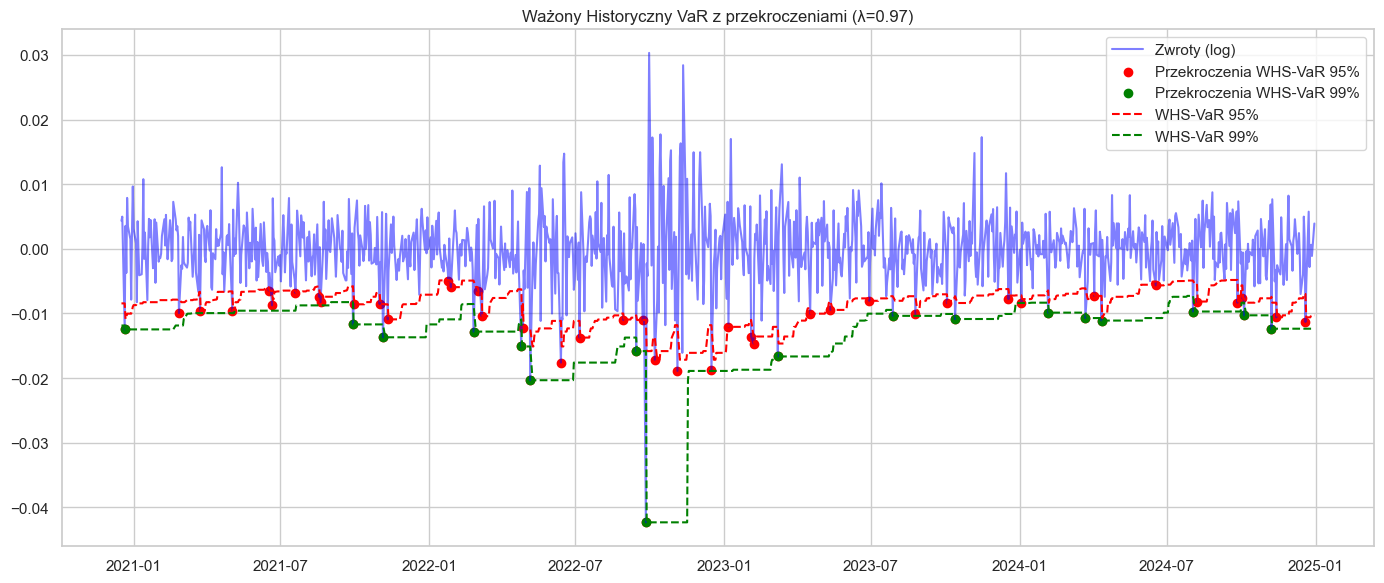

In [13]:
# Wyniki 
print("=== Testowanie wsteczne - Ważony Historyczny VaR ===")
for conf in confidence_levels:
    var_col = f'WHSVaR_{int(conf*100)}'
    backtest_results = backtest_var(aligned_returns, whs_var_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {backtest_results['n_observations']}")
    print(f"Oczekiwana liczba przekroczeń: {backtest_results['expected_exceedances']:.2f}")
    print(f"Rzeczywista liczba przekroczeń: {backtest_results['n_exceedances']}")
    print(f"Wskaźnik przekroczeń: {backtest_results['exceedance_rate']*100:.2f}%")

print("\n=== Test Kupca - Ważony Historyczny VaR ===")
for conf in confidence_levels:
    var_col = f'WHSVaR_{int(conf*100)}'
    kupiec_results = kupiec_test(aligned_returns, whs_var_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {kupiec_results['n_observations']}")
    print(f"Oczekiwana proporcja przekroczeń: {kupiec_results['expected_proportion']:.4f}")
    print(f"Rzeczywista proporcja przekroczeń: {kupiec_results['actual_proportion']:.4f}")
    print(f"Statystyka LR: {kupiec_results['LR_statistic']:.4f}")
    print(f"P-value: {kupiec_results['p_value']:.4f}")
    print(f"Czy odrzucić H0 (na poziomie 5%): {'Tak' if kupiec_results['reject_null'] else 'Nie'}")

plt.figure(figsize=(14, 6))
plt.plot(aligned_returns, label='Zwroty (log)', alpha=0.5, color='blue')

for conf in confidence_levels:
    var_col = f'WHSVaR_{int(conf*100)}'
    exceedances = aligned_returns < whs_var_df[var_col]
    plt.scatter(aligned_returns[exceedances].index, 
                aligned_returns[exceedances], 
                color='red' if conf == 0.95 else 'green',
                label=f'Przekroczenia WHS-VaR {int(conf*100)}%')

plt.plot(whs_var_df['WHSVaR_95'], label='WHS-VaR 95%', color='red', linestyle='--')
plt.plot(whs_var_df['WHSVaR_99'], label='WHS-VaR 99%', color='green', linestyle='--')
plt.title('Ważony Historyczny VaR z przekroczeniami (λ=0.97)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

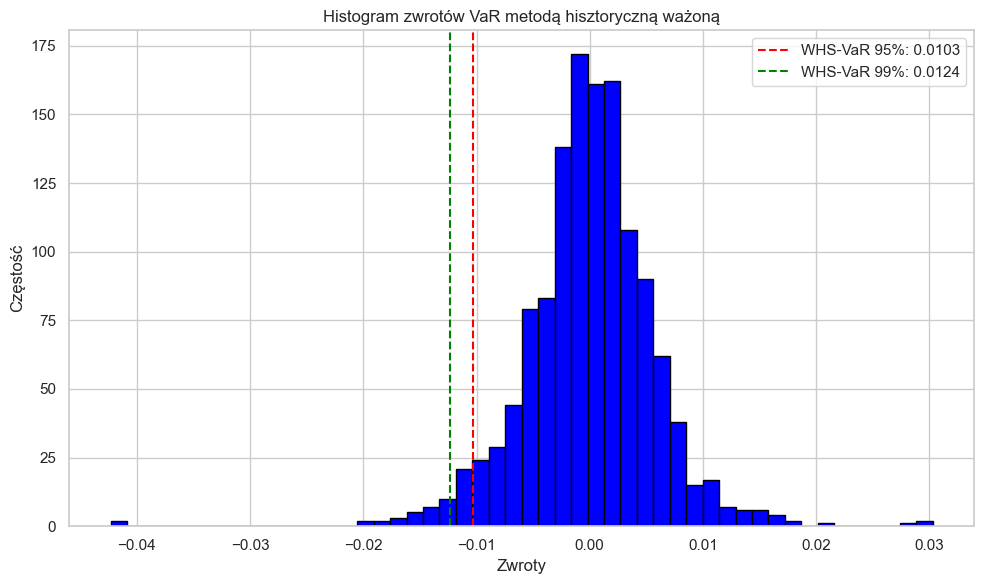

In [14]:
# Histogram rozkładu zwrotów z liniami WHS-VaR (bez %)
plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, color='blue', edgecolor='black')

# Linie WHS-VaR
var_95 = whs_var_df['WHSVaR_95'].iloc[-1]
var_99 = whs_var_df['WHSVaR_99'].iloc[-1]

plt.axvline(var_95, color='red', linestyle='--', label=f'WHS-VaR 95%: {-var_95:.4f}')
plt.axvline(var_99, color='green', linestyle='--', label=f'WHS-VaR 99%: {-var_99:.4f}')

plt.title('Histogram zwrotów VaR metodą hisztoryczną ważoną')
plt.xlabel('Zwroty')
plt.ylabel('Częstość')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
def garch_filtered_historical_var_series(returns, period=250, confidence_levels=[0.95, 0.99]):
    var_df = pd.DataFrame(index=returns.index)
    
    for i in range(period, len(returns)):
        window_returns = returns.iloc[i - period:i]
        
        # Dopasuj GARCH(1,1) do okna przesuwnego
        model = arch_model(window_returns, vol='Garch', p=1, q=1, rescale=True)
        res = model.fit(disp='off'  )
        
        # Prognozuj zmienność na następny dzień (krok i+1)
        forecast = res.forecast(horizon=1)
        forecast_vol = np.sqrt(forecast.variance.iloc[-1, 0])
        
        # Standaryzowane reszty z okna
        standardized_residuals = window_returns / res.conditional_volatility
        
        for conf in confidence_levels:
            alpha = 1 - conf
            var_percentile = np.percentile(standardized_residuals, 100 * alpha)
            var_value = var_percentile * forecast_vol
            var_df.loc[returns.index[i], f"GARCH_HS_VaR_{int(conf*100)}"] = var_value
    
    return var_df.dropna()
# Parametry
period = 250
confidence_levels = [0.95, 0.99]

# Oblicz VaR filtrowany przez GARCH
garch_hs_var_df = garch_filtered_historical_var_series(returns, period=period, confidence_levels=confidence_levels)

# Dopasuj długości
aligned_returns = returns.loc[garch_hs_var_df.index]

# Wykres
plt.figure(figsize=(14, 6))
plt.plot(aligned_returns, label='Zwroty logarytmiczne', color='blue')
plt.plot(garch_hs_var_df['GARCH_HS_VaR_95'], label='VaR 95%', linestyle='--', color='red')
plt.plot(garch_hs_var_df['GARCH_HS_VaR_99'], label='VaR 99%', linestyle='--', color='green')
plt.title('VaR metodą historyczną z użyciem GARCH z oknem kroczącym')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




ModuleNotFoundError: No module named 'arch'

=== Testowanie wsteczne ===

Poziom ufności 95.0%:
Liczba obserwacji: 1053
Oczekiwana liczba przekroczeń: 52.65
Rzeczywista liczba przekroczeń: 57
Wskaźnik przekroczeń: 5.41%

Poziom ufności 99.0%:
Liczba obserwacji: 1053
Oczekiwana liczba przekroczeń: 10.53
Rzeczywista liczba przekroczeń: 16
Wskaźnik przekroczeń: 1.52%

=== Test Kupca  ===

Poziom ufności 95.0%:
Liczba obserwacji: 1053
Oczekiwana proporcja przekroczeń: 0.0500
Rzeczywista proporcja przekroczeń: 0.0541
Statystyka LR: 0.3688
P-value: 0.5436
Czy odrzucić H0 (na poziomie 5%): Nie

Poziom ufności 99.0%:
Liczba obserwacji: 1053
Oczekiwana proporcja przekroczeń: 0.0100
Rzeczywista proporcja przekroczeń: 0.0152
Statystyka LR: 2.4763
P-value: 0.1156
Czy odrzucić H0 (na poziomie 5%): Nie


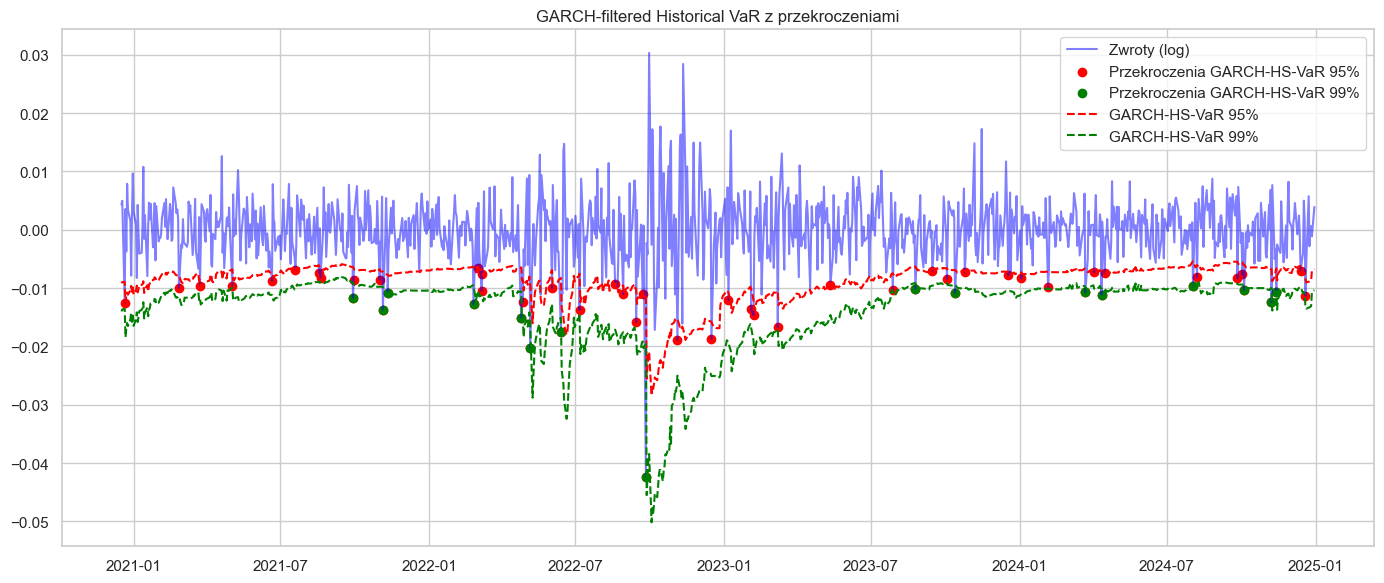

In [ ]:
# Wyniki
print("=== Testowanie wsteczne ===")
for conf in confidence_levels:
    var_col = f'GARCH_HS_VaR_{int(conf*100)}'
    backtest_results = backtest_var(aligned_returns, garch_hs_var_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {backtest_results['n_observations']}")
    print(f"Oczekiwana liczba przekroczeń: {backtest_results['expected_exceedances']:.2f}")
    print(f"Rzeczywista liczba przekroczeń: {backtest_results['n_exceedances']}")
    print(f"Wskaźnik przekroczeń: {backtest_results['exceedance_rate']*100:.2f}%")

print("\n=== Test Kupca  ===")
for conf in confidence_levels:
    var_col = f'GARCH_HS_VaR_{int(conf*100)}'
    kupiec_results = kupiec_test(aligned_returns, garch_hs_var_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {kupiec_results['n_observations']}")
    print(f"Oczekiwana proporcja przekroczeń: {kupiec_results['expected_proportion']:.4f}")
    print(f"Rzeczywista proporcja przekroczeń: {kupiec_results['actual_proportion']:.4f}")
    print(f"Statystyka LR: {kupiec_results['LR_statistic']:.4f}")
    print(f"P-value: {kupiec_results['p_value']:.4f}")
    print(f"Czy odrzucić H0 (na poziomie 5%): {'Tak' if kupiec_results['reject_null'] else 'Nie'}")


plt.figure(figsize=(14, 6))
plt.plot(aligned_returns, label='Zwroty (log)', alpha=0.5, color='blue')

for conf in confidence_levels:
    var_col = f'GARCH_HS_VaR_{int(conf*100)}'
    exceedances = aligned_returns < garch_hs_var_df[var_col]
    plt.scatter(aligned_returns[exceedances].index, 
                aligned_returns[exceedances], 
                color='red' if conf == 0.95 else 'green',
                label=f'Przekroczenia GARCH-HS-VaR {int(conf*100)}%')

plt.plot(garch_hs_var_df['GARCH_HS_VaR_95'], label='GARCH-HS-VaR 95%', color='red', linestyle='--')
plt.plot(garch_hs_var_df['GARCH_HS_VaR_99'], label='GARCH-HS-VaR 99%', color='green', linestyle='--')
plt.title('GARCH-filtered Historical VaR z przekroczeniami')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

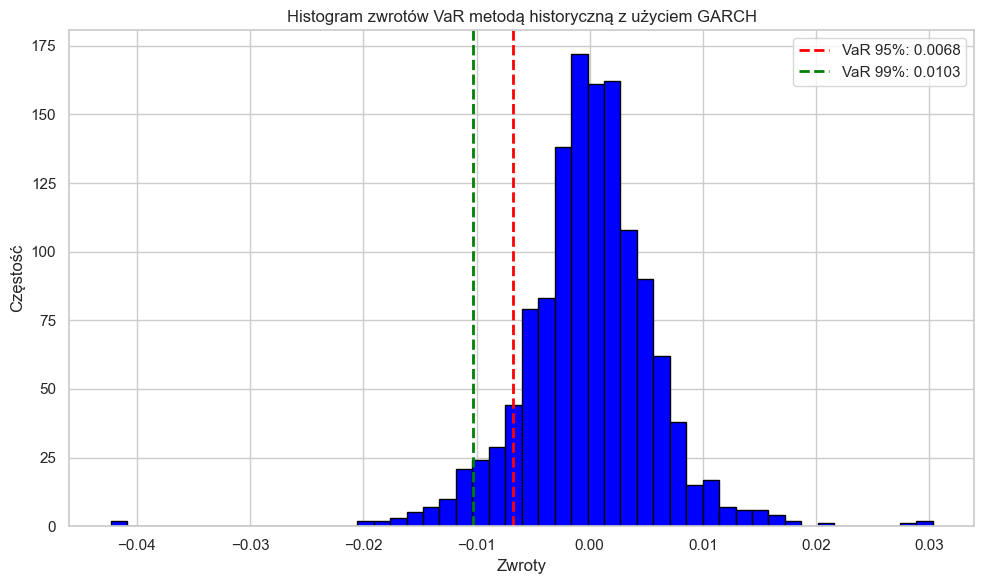

In [ ]:
# Histogram zwrotów z GARCH-HS VaR
plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, color='blue', edgecolor='black')

# Najnowsze wartości GARCH-HS VaR
var_95 = garch_hs_var_df['GARCH_HS_VaR_95'].iloc[-1]
var_99 = garch_hs_var_df['GARCH_HS_VaR_99'].iloc[-1]

# Linie pionowe
plt.axvline(var_95, color='red', linestyle='--', linewidth=2, label=f'VaR 95%: {-var_95:.4f}')
plt.axvline(var_99, color='green', linestyle='--', linewidth=2, label=f'VaR 99%: {-var_99:.4f}')

# Opis wykresu
plt.title('Histogram zwrotów VaR metodą historyczną z użyciem GARCH')
plt.xlabel('Zwroty')
plt.ylabel('Częstość')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


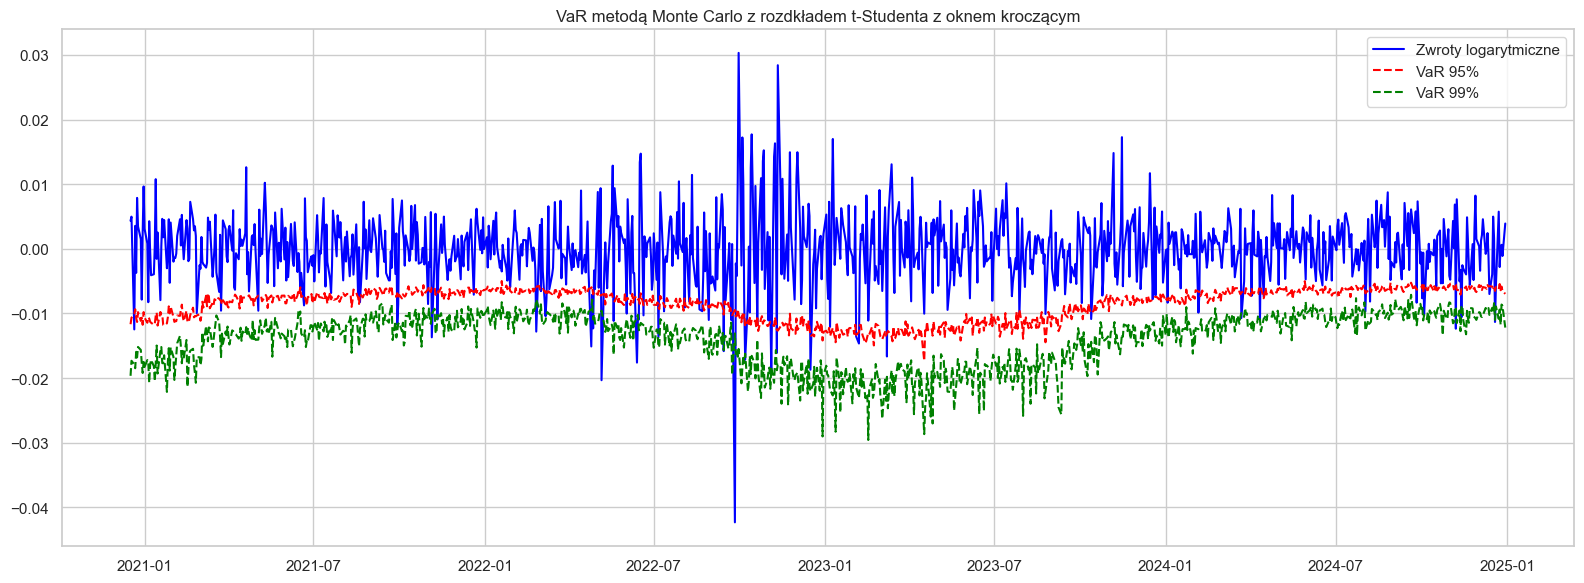

In [ ]:
from scipy.stats import t

# Parametry
window = 250
mc_sims = 500
T = 1  # 1 dzień
initial_portfolio = 1
weights = np.array([1, 0])
df_t = 5  # stopnie swobody dla t-Studenta

var_95_list = []
var_99_list = []
dates = []

for i in range(window, len(log_returns)):
    data_window = log_returns.iloc[i - window:i]
    meanReturns = data_window.mean().values
    covMatrix = data_window.cov().values

    # Symulacja z rozkładem t-Studenta
    meanM = np.tile(meanReturns, (mc_sims, 1))
    Z = t.rvs(df=df_t, size=(mc_sims, len(weights)))  # zamiast normalnego
    # Korekta dla wariancji t-Studenta
    scaling = (df_t - 2) / df_t
    L = np.linalg.cholesky(covMatrix * scaling)
    correlated_Z = Z @ L.T
    daily_returns = meanM + correlated_Z
    portfolio_returns = np.dot(daily_returns, weights)

    portfolio_end = (1 + portfolio_returns) * initial_portfolio

    var_95 = initial_portfolio - np.percentile(portfolio_end, 5)
    var_99 = initial_portfolio - np.percentile(portfolio_end, 1)

    var_95_list.append(-var_95)
    var_99_list.append(-var_99)
    dates.append(log_returns.index[i])

# Konwersja do DataFrame
var_mc_df = pd.DataFrame({
    'VaR_95_MC': var_95_list,
    'VaR_99_MC': var_99_list
}, index=dates)

# Dopasowanie zwrotów do długości wyników VaR
aligned_returns = log_returns["USD_GBP"].loc[var_mc_df.index]

# Wykres
plt.figure(figsize=(16, 6))
plt.plot(aligned_returns, label='Zwroty logarytmiczne', color='blue')
plt.plot(var_mc_df['VaR_95_MC'], label='VaR 95% ', linestyle='--', color='red')
plt.plot(var_mc_df['VaR_99_MC'], label='VaR 99% ', linestyle='--', color='green')
plt.title('VaR metodą Monte Carlo z rozdkładem t-Studenta z oknem kroczącym')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Testowanie wsteczne ===

Poziom ufności 95.0%:
Liczba obserwacji: 1053
Oczekiwana liczba przekroczeń: 52.65
Rzeczywista liczba przekroczeń: 61
Wskaźnik przekroczeń: 5.79%

Poziom ufności 99.0%:
Liczba obserwacji: 1053
Oczekiwana liczba przekroczeń: 10.53
Rzeczywista liczba przekroczeń: 18
Wskaźnik przekroczeń: 1.71%

=== Test Kupca ===

Poziom ufności 95.0%:
Liczba obserwacji: 1053
Oczekiwana proporcja przekroczeń: 0.0500
Rzeczywista proporcja przekroczeń: 0.0579
Statystyka LR: 1.3292
P-value: 0.2489
Czy odrzucić H0 (na poziomie 5%): Nie

Poziom ufności 99.0%:
Liczba obserwacji: 1053
Oczekiwana proporcja przekroczeń: 0.0100
Rzeczywista proporcja przekroczeń: 0.0171
Statystyka LR: 4.4148
P-value: 0.0356
Czy odrzucić H0 (na poziomie 5%): Tak


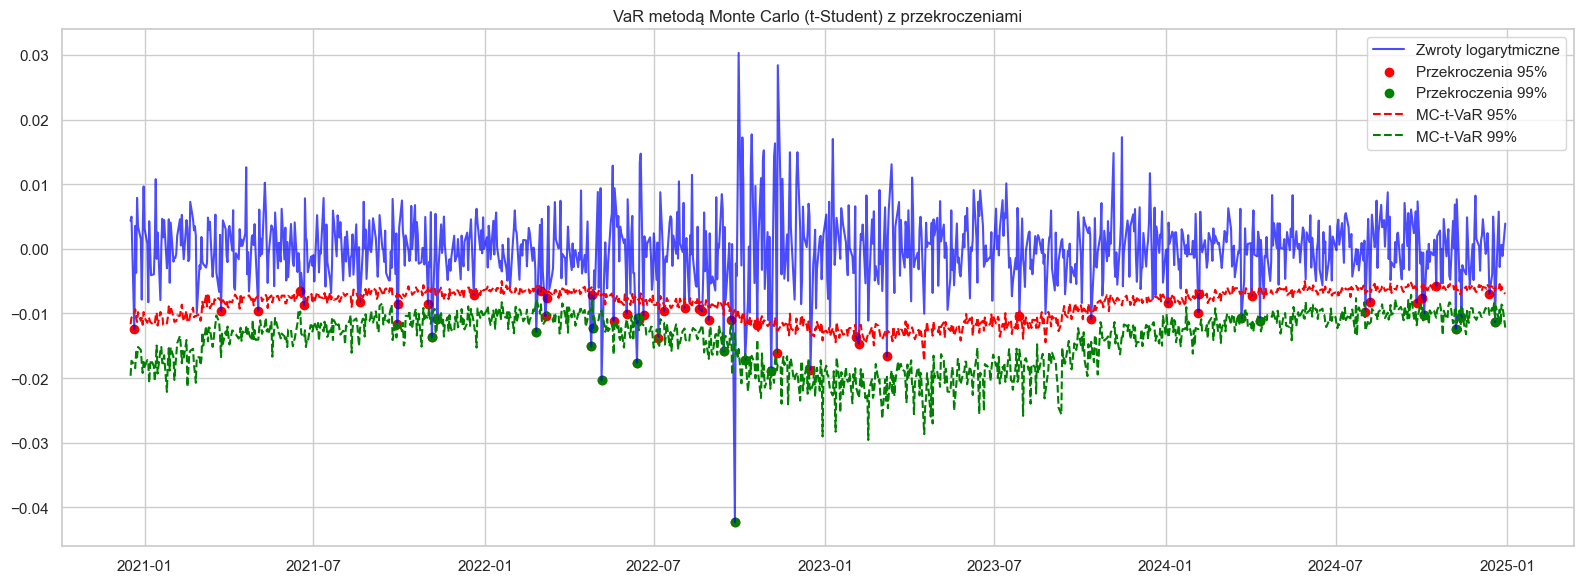

In [ ]:
# Wyniki 
print("=== Testowanie wsteczne ===")
for conf in [0.95, 0.99]:
    var_col = f'VaR_{int(conf*100)}_MC'
    backtest_results = backtest_var(aligned_returns, var_mc_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {backtest_results['n_observations']}")
    print(f"Oczekiwana liczba przekroczeń: {backtest_results['expected_exceedances']:.2f}")
    print(f"Rzeczywista liczba przekroczeń: {backtest_results['n_exceedances']}")
    print(f"Wskaźnik przekroczeń: {backtest_results['exceedance_rate']*100:.2f}%")

print("\n=== Test Kupca ===")
for conf in [0.95, 0.99]:
    var_col = f'VaR_{int(conf*100)}_MC'
    kupiec_results = kupiec_test(aligned_returns, var_mc_df[var_col], conf)
    print(f"\nPoziom ufności {conf*100}%:")
    print(f"Liczba obserwacji: {kupiec_results['n_observations']}")
    print(f"Oczekiwana proporcja przekroczeń: {kupiec_results['expected_proportion']:.4f}")
    print(f"Rzeczywista proporcja przekroczeń: {kupiec_results['actual_proportion']:.4f}")
    print(f"Statystyka LR: {kupiec_results['LR_statistic']:.4f}")
    print(f"P-value: {kupiec_results['p_value']:.4f}")
    print(f"Czy odrzucić H0 (na poziomie 5%): {'Tak' if kupiec_results['reject_null'] else 'Nie'}")

plt.figure(figsize=(16, 6))
plt.plot(aligned_returns, label='Zwroty logarytmiczne', color='blue', alpha=0.7)

for conf in [0.95, 0.99]:
    var_col = f'VaR_{int(conf*100)}_MC'
    exceedances = aligned_returns < var_mc_df[var_col]
    plt.scatter(aligned_returns[exceedances].index, 
                aligned_returns[exceedances], 
                color='red' if conf == 0.95 else 'green',
                label=f'Przekroczenia {int(conf*100)}%')

plt.plot(var_mc_df['VaR_95_MC'], label='MC-t-VaR 95%', color='red', linestyle='--')
plt.plot(var_mc_df['VaR_99_MC'], label='MC-t-VaR 99%', color='green', linestyle='--')
plt.title('VaR metodą Monte Carlo (t-Student) z przekroczeniami')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

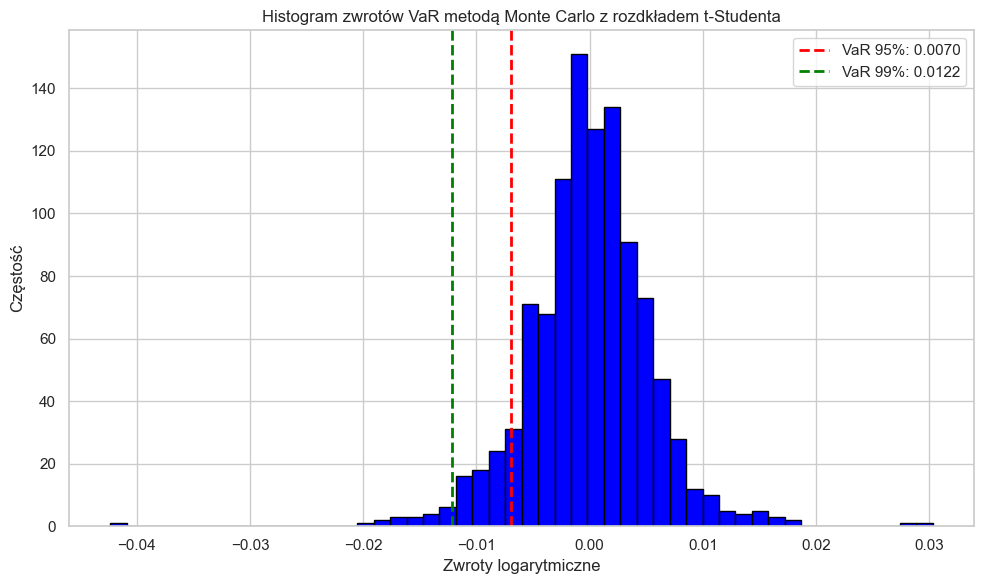

In [ ]:
# HISTOGRAM zwrotów USD_GBP z naniesionym VaR (Monte Carlo)
plt.figure(figsize=(10, 6))
plt.hist(aligned_returns, bins=50, color='blue', edgecolor='black')

# Najnowsze wartości VaR z MC
latest_var_95 = var_mc_df['VaR_95_MC'].iloc[-1]
latest_var_99 = var_mc_df['VaR_99_MC'].iloc[-1]

# Linie VaR
plt.axvline(latest_var_95, color='red', linestyle='--', linewidth=2, label=f'VaR 95%: {-latest_var_95:.4f}')
plt.axvline(latest_var_99, color='green', linestyle='--', linewidth=2, label=f'VaR 99%: {-latest_var_99:.4f}')

# Opis wykresu
plt.title('Histogram zwrotów VaR metodą Monte Carlo z rozdkładem t-Studenta')
plt.xlabel('Zwroty logarytmiczne')
plt.ylabel('Częstość')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()